In [10]:
import os

print(os.listdir('/kaggle/input/datasets/abhinav6744/mango-disease-data/mango'))

['Powdery Mildew', 'Cutting Weevil', 'Anthracnose', 'Bacterial Canker', 'Sooty Mould', 'Gall Midge', 'Healthy', 'Die Back']


In [1]:
#importing libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

2026-03-17 19:14:33.079004: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773774873.309652      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773774873.377336      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773774873.878117      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773774873.878155      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773774873.878158      55 computation_placer.cc:177] computation placer alr

In [2]:
#selecting 4 files to the working dir
import shutil

source = '/kaggle/input/datasets/abhinav6744/mango-disease-data/mango/'
dest   = '/kaggle/working/mango_dataset/'

needed = ['Anthracnose', 'Powdery Mildew', 'Bacterial Canker', 'Healthy']

for cls in needed:
    src_path = os.path.join(source, cls)
    dst_path = os.path.join(dest, cls)
    if not os.path.exists(dst_path):
        shutil.copytree(src_path, dst_path)
    print(f"Copied {cls} → {len(os.listdir(dst_path))} images")

Copied Anthracnose → 500 images
Copied Powdery Mildew → 500 images
Copied Bacterial Canker → 500 images
Copied Healthy → 500 images


In [3]:
#Load and augment data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dest,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    dest,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Classes:", train_generator.class_indices)
NUM_CLASSES = len(train_generator.class_indices)

Found 1600 images belonging to 4 classes.
Found 400 images belonging to 4 classes.
Classes: {'Anthracnose': 0, 'Bacterial Canker': 1, 'Healthy': 2, 'Powdery Mildew': 3}


In [4]:
#model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773775123.033811      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773775123.039935      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
#Training
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1773775313.779815     195 service.cc:152] XLA service 0x7be5bc004e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773775313.779848     195 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773775313.779851     195 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773775314.190680     195 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/50 ━━━━━━━━━━━━━━━━━━━━ 5:04 6s/step - accuracy: 0.3438 - loss: 1.3676

I0000 00:00:1773775318.283274     195 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 210ms/step - accuracy: 0.2993 - loss: 1.5034 - val_accuracy: 0.5550 - val_loss: 1.1357
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.6396 - loss: 0.8417 - val_accuracy: 0.7525 - val_loss: 0.8746
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.8501 - loss: 0.4537 - val_accuracy: 0.8100 - val_loss: 0.6079
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.9114 - loss: 0.2434 - val_accuracy: 0.7825 - val_loss: 0.6636
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.9070 - loss: 0.2834 - val_accuracy: 0.8725 - val_loss: 0.3909
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.9540 - loss: 0.1388 - val_accuracy: 0.8775 - val_loss: 0.3627
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.9518 - loss: 0.1532 - val_accuracy: 0.9450 - val_loss: 0.1890
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.9451 - loss: 0.1696 - val_accuracy: 0.9250 - val

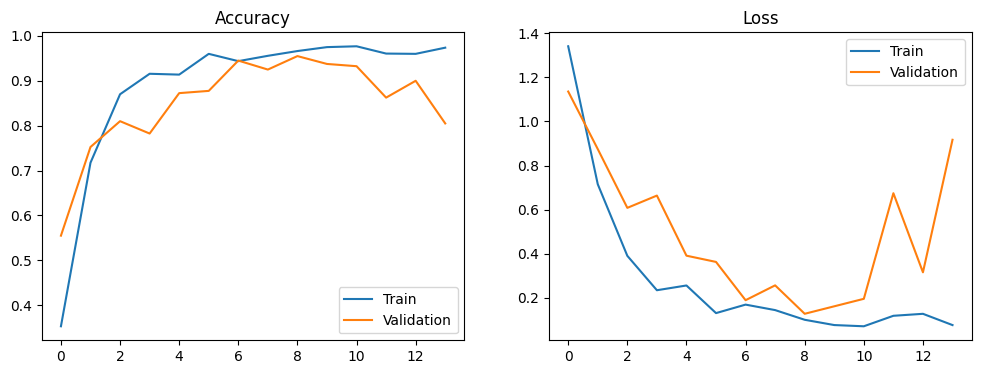

In [9]:
#Ploting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.legend()

plt.show()

In [10]:
#Save 
model.save('/kaggle/working/mango_model.h5')
labels = [label for label, index in sorted(train_generator.class_indices.items(), key=lambda x: x[1])]
with open('/kaggle/working/mango_labels.txt', 'w') as f:
    for label in labels:
        f.write(label + '\n')
print("Labels:", labels)

Model saved!
Labels: ['Anthracnose', 'Bacterial Canker', 'Healthy', 'Powdery Mildew']
